 hugging face model



alles staat in de commnets. zo zou je het eat model van hugging face op de videokaart zetten om later geluid door het netwerk te halen. het model id is hetzelfde als verderop in het notebook.


## Stap 1, Wang (2025), 2.1 Backbone: EAT op de GPU

In het  rapport van Wang staat dat ze EAT gebruiken: een groot netwerk dat al op veel audio (AudioSet-2M) is voortraind. Zo krijg je sterke geluids-“features” zonder van nul te beginnen. Deze codecel hoort daarbij, het laadt hetzelfde soort EAT-model op de GPU, klaar om straks geluid door het netwerk te halen, in principe de eerste bouwsteen van hun ASD-systeem (Fig. 1).

(Dit komt uit Wang 2025, sectie 2.1 (EAT-encoder als feature-extractor)


In [5]:
# import torchaudio
# import torch
# import soundfile as sf
# import numpy as np
# from transformers import AutoModel

# model_id = "worstchan/EAT-base_epoch30_finetune_AS2M"
# model = AutoModel.from_pretrained(model_id, trust_remote_code=True).eval().cuda()

## Stap 2, Wang (2025), 2.1 Backbone,  mel-spectrogram → EAT → embedding
Wang beschrijft dat de EAT-encoder mel-spectrogram (kaldi fbank) als invoer krijgt, in stukjes () (patches) verwerkt, en daarna een diepe embedding maakt. In de paper gaat het gemiddelde over de patch-embeddings naar de classifier. Deze (uitgecommentarieerde) cel volgt die route: wav → mel → normaliseren → extract_features → vector opslaan (als npy bestand). hetzelfde idee als geluid omzetten naar een compacte representatie vóór fine-tuning.

(Wang 2025, 2.1 (mel-invoer, encoder, embedding voor de kop))


In [6]:


# source_file = "/path/to/input.wav"
# target_file = "/path/to/output.npy"
# target_length = 1024    # Recommended: 1024 for 10s audio
# norm_mean = -4.268
# norm_std = 4.569

# # Load and resample audio
# wav, sr = sf.read(source_file)
# waveform = torch.tensor(wav).float().cuda()
# if sr != 16000:
#     waveform = torchaudio.functional.resample(waveform, sr, 16000)

# # Normalize and convert to mel-spectrogram
# waveform = waveform - waveform.mean()
# mel = torchaudio.compliance.kaldi.fbank(
#     waveform.unsqueeze(0),
#     htk_compat=True,
#     sample_frequency=16000,
#     use_energy=False,
#     window_type='hanning',
#     num_mel_bins=128,
#     dither=0.0,
#     frame_shift=10
# ).unsqueeze(0)

# # Pad or truncate
# n_frames = mel.shape[1]
# if n_frames < target_length:
#     mel = torch.nn.ZeroPad2d((0, 0, 0, target_length - n_frames))(mel)
# else:
#     mel = mel[:, :target_length, :]

# # Normalize
# mel = (mel - norm_mean) / (norm_std * 2)
# mel = mel.unsqueeze(0).cuda()  # shape: [1, 1, T, F]

# # Extract features
# with torch.no_grad():
#     feat = model.extract_features(mel)

# feat = feat.squeeze(0).cpu().numpy()
# np.save(target_file, feat)
# print(f"Feature shape: {feat.shape}")
# print(f"Saved to: {target_file}")



deze code cell hieronder zoekt alle csv bestanden onder je dcase map. alleen rijen waar train in de bestandsnaam voorkomt tellen mee. per rij wordt een unieke labeltekst gemaakt uit machine en source of target en attributen. je krijgt een gesorteerde lijst van alle klassen plus de functie get_dcase_num_classes en de klasse dcase label encoder die tekst omzet naar een geheel getal voor het netwerk.


## Stap 3, Wang (2025), 2.2 Fine-tuning, labels (attribuut + domein)

Ze trainen het systeem door machines te classificeren: soms met attributen, soms alleen met domein (source/target) als er geen attributen zijn. Deze code bouwt alle unieke trainingsklassen uit de DCASE-CSV’s en een encoder die tekstlabels omzet naar nummers, precies wat je nodig hebt vóór de classificatiekop en ArcFace.

(Wang 2025, 2.2 (classificatie op attributen en domeinen))


In [7]:
import pandas as pd
import os


def _normalize_attr_value(v):
    """Zelfde tekst als in de label-lijst: bv. float 1.0 uit pandas wordt '1'."""
    if pd.isna(v):
        return ""
    s = str(v).strip()
    try:
        x = float(s.replace(",", "."))
        if x == int(x):
            return str(int(x))
    except ValueError:
        pass
    return s


def _iter_machine_attribute_csvs(base_path):
    # Standaard: raw/<machine>/attributes_00.csv. Anders: dieper (verkeerd uitgepakte mappen).
    if not os.path.isdir(base_path):
        return
    any_shallow = False
    for name in sorted(os.listdir(base_path)):
        p = os.path.join(base_path, name)
        if not os.path.isdir(p):
            continue
        ap = os.path.join(p, "attributes_00.csv")
        if os.path.isfile(ap):
            any_shallow = True
            yield name, ap
    if any_shallow:
        return
    for root, _, files in os.walk(base_path):
        if "attributes_00.csv" not in files:
            continue
        ap = os.path.join(root, "attributes_00.csv")
        machine = os.path.basename(root)
        yield machine, ap


def get_dcase_num_classes(base_path):
    all_configs = []

    for machine_type, file in _iter_machine_attribute_csvs(base_path):
        df = pd.read_csv(file)

        train_df = df[df["file_name"].str.contains("train", na=False)].copy()

        for _, row in train_df.iterrows():
            file_name = str(row["file_name"])

            domain = "source" if "source" in file_name else "target"

            attr_cols = [col for col in train_df.columns if col.endswith("v")]
            attr_values = [_normalize_attr_value(row[col]) for col in attr_cols if pd.notna(row[col])]
            attr_values = [v for v in attr_values if v and v.lower() != "noattribute"]

            if not attr_values or all(v.lower() == "noattribute" for v in attr_values):
                config_label = f"{machine_type}_{domain}"
            else:
                attrs_str = "_".join(attr_values)
                config_label = f"{machine_type}_{domain}_{attrs_str}"

            all_configs.append(config_label)

    unique_classes = sorted(list(set(all_configs)))

    print(f"Total Unique Training Classes: {len(unique_classes)}")
    return unique_classes, len(unique_classes)


class DCASELabelEncoder:
    def __init__(self, unique_configs):
        self.str_to_int = {label: i for i, label in enumerate(unique_configs)}
        self.int_to_str = {i: label for i, label in enumerate(unique_configs)}
        self.num_classes = len(unique_configs)
        # ToyCar/ToyTrain in labels zijn hoofdlettergevoelig; map lowercase -> canoniek
        self._machine_canonical = {}
        for label in unique_configs:
            parts = label.split("_")
            if len(parts) >= 2 and parts[1] in ("source", "target"):
                m = parts[0]
                self._machine_canonical.setdefault(m.lower(), m)

    def encode(self, machine, domain, attributes=None, verbose=False):
        machine = str(machine).strip()
        machine = self._machine_canonical.get(machine.lower(), machine)
        domain = domain.strip().lower()

        if not attributes or attributes == ["noAttribute"]:
            label_str = f"{machine}_{domain}"
        else:
            clean_attrs = [_normalize_attr_value(a) for a in attributes]
            clean_attrs = [a for a in clean_attrs if a and a.lower() != "noattribute"]
            attrs_str = "_".join(clean_attrs)
            label_str = f"{machine}_{domain}_{attrs_str}"

        if verbose:
            print(f"Searching for: '{label_str}'")

        if label_str not in self.str_to_int:
            print(f"Warning: {label_str} not found in encoder labels!")
            print(f"Available labels: {list(self.str_to_int.keys())[:]}")

        return self.str_to_int.get(label_str, -1)


 hieronder is een 
voorbeeld om een label met de hand te coderen. staat in de comments; haal de hekjes weg als je de encoder los wilt proberen.


## Stap 4, Wang (2025), 2.2 Fine-tuning, voorbeeld van label-encoding

Zelfde onderdeel als stap 3: even proberen of één combinatie (machine + domein + attributen) goed naar het juiste klasse-nummer gaat. Handig vóór je grote training start, sluit aan bij hun supervised fine-tuning op vaste klassen.

(Wang 2025, 2.2 (supervised labels voor de classificatietak))


In [8]:
# labels_list, _ = get_dcase_num_classes("data\\dcase2025t2\\dev_data\\raw\\")
# encoder = DCASELabelEncoder(labels_list)
# target_id = encoder.encode("valve", "source", ["0", "5"])
# target_id


## Stap 5, Wang (2025), 2.1 + 2.2: Dataset (mel + label)


deze pytorch dataset hieronder hoort bij training. voor elke rij opent het het wav pad, resamplet naar 16 kHz, maakt een mel met dezelfde stappen als eat, knipt of vult tot lengte 1024, en haalt het klasse nummer uit de encoder. get item geeft mel en label terug.


De backbone (EAT) wil gestandaardiseerde mel-features, fine-tuning wil bij elk fragment het juiste label. Deze Dataset leest wav, maakt mel zoals EAT verwacht, en koppelt het label uit je encoder, de brug tussen ruwe data en het model, zoals in hun pijplijn backbone → classifier.

Bron: Wang 2025, 2.1 (invoer) en 2.2 (trainen met labels)


In [9]:
import torch
import torchaudio
import pandas as pd
import os
from torch.utils.data import Dataset


def _resolve_train_wav_path(base_path, row):
    # csv rij naar wav pad. Ondersteunt platte layout raw/<machine>/... en geneste
    # layout raw/bearing/bearing/<machine>/... (typisch na verkeerd uitpakken).
    fn = str(row["file_name"]).replace("\\\\", "/").replace("\\", "/")
    if "/" in fn:
        rel = fn.split("/")
    else:
        machine = row.get("_machine")
        if machine is None or (isinstance(machine, float) and pd.isna(machine)):
            raise ValueError(
                f"file_name zonder map maar geen _machine in rij: {fn!r}. draai create_master_dataframe opnieuw."
            )
        stem = os.path.basename(fn)
        if not stem.lower().endswith(".wav"):
            stem = stem + ".wav"
        rel = [str(machine), "train", stem]
    direct = os.path.normpath(os.path.join(base_path, *rel))
    if os.path.isfile(direct):
        return direct
    nested = os.path.normpath(os.path.join(base_path, "bearing", "bearing", *rel))
    if os.path.isfile(nested):
        return nested
    return direct


def _waveform_mono_16k_zero_mean(waveform, sr):
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
    return waveform - waveform.mean()


class EATDCASEDataset(Dataset):
    def __init__(self, df, encoder, base_path, target_length=1024, tse_models=None):
        self.df = df
        self.encoder = encoder
        self.base_path = base_path
        self.target_length = target_length
        self.tse_models = tse_models if tse_models else None
        self.norm_mean = -4.268
        self.norm_std = 4.569

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = _resolve_train_wav_path(self.base_path, row)

        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"wav ontbreekt: {file_path}")

        fn = str(row["file_name"]).replace("\\\\", "/").replace("\\", "/")
        if "_machine" in self.df.columns and pd.notna(row.get("_machine")):
            machine = str(row["_machine"]).strip()
        elif "/" in fn:
            machine = fn.split("/")[0]
        else:
            machine = str(row.get("_machine", "")).strip()

        domain = "source" if "source" in fn else "target"

        attr_cols = [col for col in self.df.columns if col.endswith("v")]
        attr_values = [_normalize_attr_value(row[col]) for col in attr_cols if pd.notna(row[col])]
        attr_values = [v for v in attr_values if v and v.lower() != "noattribute"]

        target_id = self.encoder.encode(machine, domain, attr_values, verbose=False)

        waveform, sr = torchaudio.load(file_path)
        waveform = _waveform_mono_16k_zero_mean(waveform, sr)

        tse_net = None
        if self.tse_models:
            tse_net = self.tse_models.get(machine)

        if tse_net is not None:
            with torch.no_grad():
                wav = waveform.to(dtype=torch.float32)
                enhanced = tse_net(wav)
                if enhanced.dim() == 1:
                    waveform = enhanced.unsqueeze(0)
                else:
                    waveform = enhanced

        mel = torchaudio.compliance.kaldi.fbank(
            waveform,
            htk_compat=True,
            sample_frequency=16000,
            use_energy=False,
            window_type="hanning",
            num_mel_bins=128,
            dither=0.0,
            frame_shift=10,
        )

        n_frames = mel.shape[0]
        if n_frames < self.target_length:
            pad_amount = self.target_length - n_frames
            mel = torch.nn.functional.pad(mel, (0, 0, 0, pad_amount), "constant", 0)
        else:
            mel = mel[: self.target_length, :]

        mel = (mel - self.norm_mean) / (self.norm_std * 2)

        return mel, torch.tensor(target_id).long()


## Stap 6, Wang (2025), 2.2 Fine-tuning, alle traindata in één tabel (master_df)

 hieronder
 is de functie zoekt alle csv bestanden in de map, houdt alleen trainrijen, en plakt alles aan elkaar tot een grote dataframe. dat wordt master df met alle train samples van alle machines in ongeveer zevenduizend rijen. onderaan maakt de cel master df echt aan en print hoeveel rijen het zijn.


Wang en collega's fine-tunen op alle machinetypes samen en noemen ook extra schone data en ruis-augmentatie waar de dataset dat toelaat. master_df plakt alle train-regels uit de CSV’s aan elkaar, één grote trainingslijst, vergelijkbaar met “alles op één hoop voor supervised learning”.

Bron: Wang 2025, 2.2 (fine-tunen over machine types; uitbreiding trainset).


In [10]:
import os
import pandas as pd


def _first_attributes_csv_under(start_dir: str):
    if not os.path.isdir(start_dir):
        return None
    for root, _, files in os.walk(start_dir):
        if "attributes_00.csv" in files:
            return os.path.join(root, "attributes_00.csv")
    return None


def _dcase_data_root_from_csv(attr_csv: str) -> str:
    """CSV pad .../<machine>/attributes_00.csv. file_name in CSV is <machine>/train/...."""
    d_machine = os.path.dirname(os.path.abspath(attr_csv))
    return os.path.dirname(d_machine)


def _resolve_dcase_base_path() -> str:
    """Zoekt data onder dev_data/raw, rekent om bij geneste mappen (bijv. raw/bearing/bearing/valve)."""
    tail = ("data", "dcase2025t2", "dev_data", "raw")
    cwd = os.getcwd()
    cands = [
        os.path.join(cwd, *tail),
        os.path.join(cwd, "Wang_EAT_Q4_Week_1", *tail),
        os.path.join(cwd, "..", *tail),
        os.path.join(cwd, "..", "Wang_EAT_Q4_Week_1", *tail),
        os.path.join(cwd, "..", "Victor_week_9", *tail),
        os.path.join(cwd, "..", "..", "Victor_week_9", *tail),
    ]
    for c in cands:
        c = os.path.normpath(c)
        first = _first_attributes_csv_under(c)
        if not first:
            continue
        root = _dcase_data_root_from_csv(first)
        print("BASE_PATH (data root voor valve/train/... in CSV):", root)
        return root
    raise FileNotFoundError(
        "Geen attributes_00.csv onder verwachte dev_data/raw paden. Huidige werkmap: " + cwd
    )


def create_master_dataframe(base_path):
    all_dfs = []
    for machine_type, csv_path in _iter_machine_attribute_csvs(base_path):
        df = pd.read_csv(csv_path)
        train_only = df[df["file_name"].str.contains("train", na=False)].copy()
        train_only = train_only.copy()
        train_only["_machine"] = machine_type
        all_dfs.append(train_only)
    if not all_dfs:
        raise ValueError(
            "Geen enkele machine-CSV met trainrijen. Controleer base_path: "
            + os.path.abspath(base_path)
        )
    return pd.concat(all_dfs, ignore_index=True)


BASE_PATH = _resolve_dcase_base_path()
master_df = create_master_dataframe(BASE_PATH)
print(f"Total training samples: {len(master_df)}")
master_df.tail(4000)


BASE_PATH (data root voor valve/train/... in CSV): c:\Users\lucth\Downloads\Sorama Internship\Wang_EAT_Q4_Week_1\data\dcase2025t2\dev_data\raw\bearing\bearing
Total training samples: 7000


,file_name,d1p,d1v,d2p,d2v,d3p,d3v,_machine
3000,fan/train/section_00_source_train_normal_0000_...,n,B,NaN,NaN,NaN,NaN,fan
3001,fan/train/section_00_source_train_normal_0001_...,n,B,NaN,NaN,NaN,NaN,fan
3002,fan/train/section_00_source_train_normal_0002_...,n,B,NaN,NaN,NaN,NaN,fan
3003,fan/train/section_00_source_train_normal_0003_...,n,B,NaN,NaN,NaN,NaN,fan
3004,fan/train/section_00_source_train_normal_0004_...,n,B,NaN,NaN,NaN,NaN,fan
...,...,...,...,...,...,...,...,...
6995,valve/train/section_00_target_train_normal_000...,v1pat,5,v2pat,5,NaN,NaN,valve
6996,valve/train/section_00_target_train_normal_000...,v1pat,5,v2pat,5,NaN,NaN,valve
6997,valve/train/section_00_target_train_normal_000...,v1pat,5,v2pat,5,NaN,NaN,valve
6998,valve/train/section_00_target_train_normal_000...,v1pat,5,v2pat,5,NaN,NaN,valve


rubriek test


## Stap 7, Wang (2025), 2.1-2.2: sanity check (encoder + dataset)

hieronder is een
testcel: haalt de klassenlijst op, maakt de encoder, bouwt een klein dataset bijvoorbeeld alleen valve, en probeert een sample te laden. als het lukt zie je de vorm van de mel en het labelnummer om paden en labels te controleren voordat je traint.


Deze test cell doet Wang niet in de paper, maar wel dezelfde datastroom als zij gebruiken: eerst labels kloppen, dan één batch audio laden. Zo voorkom je fouten in paden of labels vóór de zware training (EAT + classificatie).

(zelfde pijplijn als Wang 2025 2.1-2.2)


In [11]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader

# Raw root (relative to notebook cwd; match step 6).
BASE_PATH = r"data\dcase2025t2\dev_data\raw"
if "BASE_PATH" in globals() and globals().get("BASE_PATH"):
    BASE_PATH = os.path.normpath(str(globals()["BASE_PATH"]))

# Valve CSV: may be raw/valve/... or raw/bearing/bearing/valve/... (discover with iterator)
CSV_PATH = None
for m, ap in _iter_machine_attribute_csvs(BASE_PATH):
    if m == "valve":
        CSV_PATH = ap
        break
if not CSV_PATH:
    raise FileNotFoundError(
        "No valve/attributes_00.csv under " + os.path.abspath(BASE_PATH)
    )
print("CSV for test:", os.path.abspath(CSV_PATH))

# 1. TEST THE LABEL ENCODER
print("Step 1: Testing Label Encoder...")
labels_list, _ = get_dcase_num_classes(BASE_PATH)
encoder = DCASELabelEncoder(labels_list)
print(f"Total classes found: {len(labels_list)}")

# 2. TEST DATASET LOADING
print("\nStep 2: Testing Dataset Loading...")
df = pd.read_csv(CSV_PATH)
df_train = df[df["file_name"].str.contains("train")].copy()

dataset = EATDCASEDataset(
    df=df_train,
    encoder=encoder,
    base_path=BASE_PATH,
    target_length=1024,
)

try:
    mel, label_id = dataset[0]
    print("Dataset succesfully loaded a sample")
    print(f"Mel shape: {mel.shape}")
    print(f"Target ID: {label_id.item()}")
    print(f"File tested: {df_train.iloc[0]['file_name']}")
except Exception as e:
    print("Error during loading.")
    print(f"Error details: {e}")
    sample_file = df_train.iloc[0]["file_name"]
    parts = str(sample_file).replace("\\", "/").split("/")
    direct = os.path.normpath(os.path.join(BASE_PATH, *parts))
    nested = os.path.normpath(os.path.join(BASE_PATH, "bearing", "bearing", *parts))
    print("Try flat:  ", direct, "exists", os.path.isfile(direct))
    print("Try nested:", nested, "exists", os.path.isfile(nested))


CSV for test: c:\Users\lucth\Downloads\Sorama Internship\Wang_EAT_Q4_Week_1\data\dcase2025t2\dev_data\raw\bearing\bearing\valve\attributes_00.csv
Step 1: Testing Label Encoder...
Total Unique Training Classes: 51
Total classes found: 51

Step 2: Testing Dataset Loading...
Dataset succesfully loaded a sample
Mel shape: torch.Size([1024, 128])
Target ID: 46
File tested: valve/train/section_00_source_train_normal_0000_v1pat_00_v2pat_05.wav


 hieronder
staat in commentaar. kan een batch uit de dataloader halen en mels plotten. alleen voor visuele controle, niet nodig voor training.


## Stap 8 (optioneel), Wang (2025), 2.1 Backbone, mels bekijken

 Wang legt de nadruk op goede invoerfeatures (mel → EAT). Deze cel is alleen om met je ogen te checken of de mel-spectrogrammen er gezond uitzien. Staat niet letterlijk zo in de paper, maar hoort bij “controleer je backbone-invoer”.

(Wang 2025, 2.1 (mel als invoer van de encoder))


  Batch loaded.
Mel Tensor Shape: torch.Size([4, 1024, 128])
Labels in Batch: [46, 46, 46, 46]


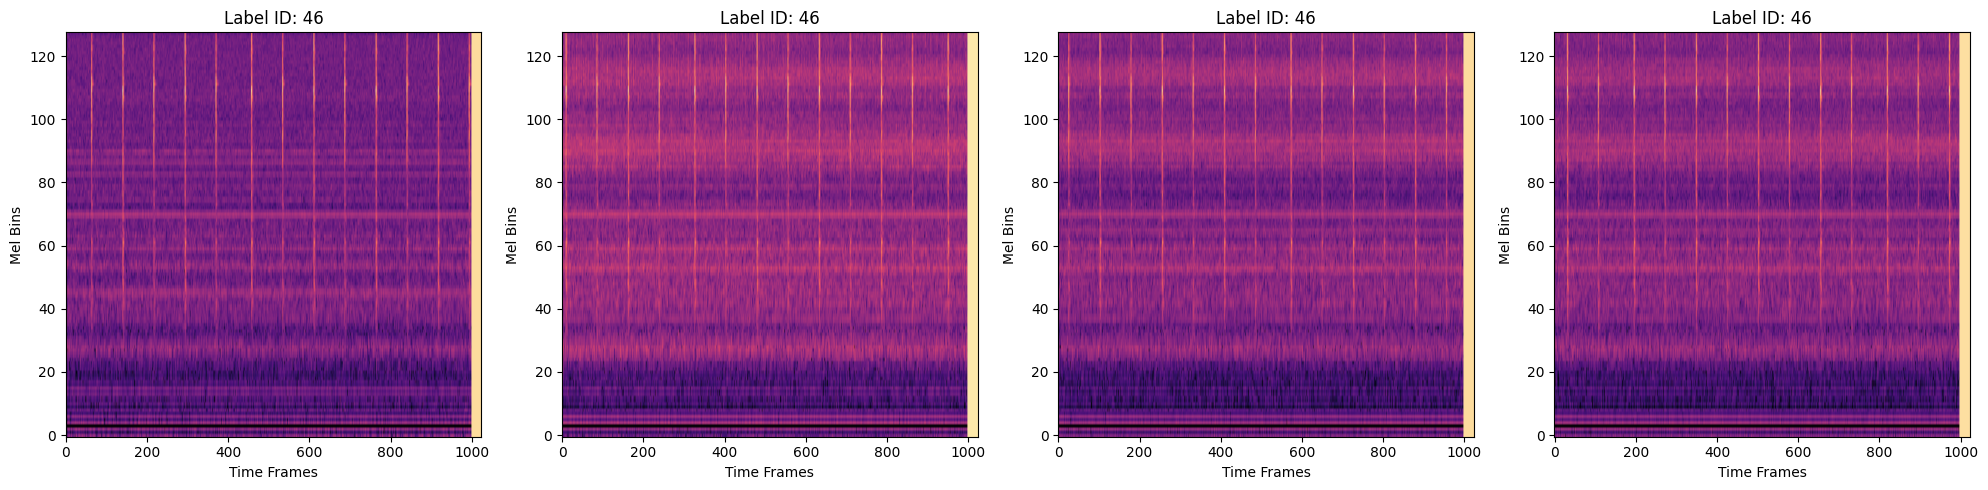

In [12]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# 1. DataLoader ,uses train_dataset once you have run the full-data cell; else Stap 7's `dataset`
_vis_ds = globals().get("train_dataset")
if _vis_ds is None:
    _vis_ds = globals().get("dataset")
if _vis_ds is None:
    raise NameError(
        "No train_dataset or dataset: run the cell that builds train_dataset, or at least "
        "Stap 7 (sanity check) so `dataset` exists."
    )
test_loader = DataLoader(_vis_ds, batch_size=4, shuffle=False)

# 2. Grab exactly one batch
try:
    batch_mel, batch_labels = next(iter(test_loader))
    print(f"  Batch loaded.")
    print(f"Mel Tensor Shape: {batch_mel.shape}")  # e.g. [B, 1024, 128]
    print(f"Labels in Batch: {batch_labels.tolist()}")
except Exception as e:
    print(f" Error loading batch: {e}")
    # This usually means a file path in your CSV is wrong
    raise

# 3. Visualize the Mel-spectrograms (up to 4 panels; fewer if batch is smaller)
n_show = min(4, int(batch_mel.shape[0]))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
axes = [axes] if n_show == 1 else list(axes)
for i in range(n_show):
    # .T (Transpose) if needed to get Time on X-axis and Freq on Y-axis
    # We use .log2() for visualization because raw power scales are hard to see
    img = batch_mel[i].cpu().numpy().T
    axes[i].imshow(img, origin="lower", aspect="auto", cmap="magma")
    axes[i].set_title(f"Label ID: {batch_labels[i].item()}")
    axes[i].set_xlabel("Time Frames")
    axes[i].set_ylabel("Mel Bins")

plt.tight_layout()
plt.show()

## Stap 9, Wang (2025), 2.2 Fine-tuning: ArcFace-loss (s, m)

hieronder staat de module arcface loss. die traint zo dat embeddings beter te onderscheiden zijn tussen klassen met een marge op de hoek in cosinus ruimte, vergelijkbaar met wang. out features moet gelijk zijn aan je aantal klassen bijvoorbeeld eenenvijftig.


In Wang et al., 2025 schrijven ze duidelijk dat ze tijdens fine-tuning ArcFace gebruiken, met een formule met een hoek tussen embedding en klassen-gewichten en hyperparameters s en m. Die loss maakt embeddings van verschillende klassen duidelijker uit elkaar in cosinus/hoek-ruimte, het trainingsdoel achter hun classificatiekop.

Bron: Wang 2025, 2.2 + formule met ArcFace / hoekmarge.


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFaceLoss, self).__init__()
        self.s = s
        self.m = m
        # weight represents the 'center' of each of your 51 classes
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, input, label):
        # 1. Normalize features and weights to get cosine similarity
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        
        # 2. Calculate the angle (theta)
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        
        # 3. Add the margin to the target class
        target_logit = torch.cos(theta + self.m)
        
        # 4. Replace original cosine with margined logit for the ground truth
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1.0)
        output = (one_hot * target_logit) + ((1.0 - one_hot) * cosine)
        
        # 5. Scale by 's' (temperature)
        return F.cross_entropy(output * self.s, label)

## Stap 10, Wang (2025), 2.1 + 2.2.2: EAT model laden + LoRA-idee

 deze cel hieronder definieert ook een klasse eat lora model met torch hub naar microsoft eat. dat is niet hetzelfde als het checkpoint worstchan eat dat je met hugging face laadt. meestal negeer je deze cel of gebruik je alleen het idee; de echte setup staat bij lora met automodel.


In Wangs paragraaf 2.1 staat at EAT de backbone blijft (feature-extractor). En in paragraaf 2.2.2, noemen ze EAT- (fine-tune), het grootste deel van het voorgetrainde netwerk blijft vast, en er komen kleine, trainbare “bijlagen” (low ranks) bij. Deze cel laadt het HF-checkpoint en toont ook een schets met `torch.hub`, let op: dat tweede stuk is hetzelfde idee, maar niet dezelfde code als Hugging Face.

Bron: Wang 2025, 2.1 (EAT) en 2.2.2 (LoRA: kleine matrices B en A bij het grote gewicht W₀)


In [14]:
import torch
import torch.nn as nn
from transformers import AutoModel
import transformers.modeling_utils as _hf_modeling_utils

_pt = _hf_modeling_utils.PreTrainedModel
if not getattr(_hf_modeling_utils, "_eat_tied_weights_compat", False) and hasattr(
    _pt, "_adjust_tied_keys_with_tied_pointers"
):
    _adjust_orig = _pt._adjust_tied_keys_with_tied_pointers

    def _adjust_tied_keys_eat_compat(self, missing_keys):
        if not hasattr(self, "all_tied_weights_keys"):
            self.all_tied_weights_keys = {}
        return _adjust_orig(self, missing_keys)

    _pt._adjust_tied_keys_with_tied_pointers = _adjust_tied_keys_eat_compat
    _hf_modeling_utils._eat_tied_weights_compat = True

# Assuming you have the EAT library or hub model loaded
# from eat_model import EAT 

model_id = "worstchan/EAT-base_epoch30_finetune_AS2M"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True).eval().cuda()

class EATLoRAModel(nn.Module):
    def __init__(self, model_name="EAT-base", lora_rank=8):
        super().__init__()
        # 1. Load the pre-trained backbone
        self.backbone = torch.hub.load('microsoft/EAT', model_name) 
        
        # 2. Freeze the backbone weights
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # 3. Inject LoRA layers (Conceptual - depends on your LoRA implementation)
        # Most libraries like 'peft' can do this automatically:
        # self.backbone = get_peft_model(self.backbone, LoraConfig(r=lora_rank))
        
        # 4. Final Projection (EAT-base outputs a 768-dim vector)
        self.embedding_size = 768

    def forward(self, x):
        # x: [Batch, Time, Freq] -> [Batch, 1024, 128]
        # The backbone processes patches and returns a global embedding
        embedding = self.backbone.extract_features(x) 
        return embedding # This 768-dim vector goes into ArcFace

c:\Users\lucth\miniconda3\envs\sorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\lucth\miniconda3\envs\sorama\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights: 100%|██████████| 154/154 [00:00<00:00, 268.36it/s, Materializing param=model.pre_norm.weight]                   


## Stap 11, Wang (2025), 2.2.2 LoRA fine-tune instellen, PEFT (parameter efficient fine tuning) op EAT


Laadt automodel from pretrained voor eat op cuda en wikkelt het model in met peft lora zodat onder andere qkv en proj trainbare lage rang updates krijgen. Print trainable parameters laat zien hoeveel procent van de gewichten echt meedoet.


Dit is dus de EAT-LoRA variant waarbij we het pretrained netwerk freezen en trainen alleen dunne lagen (hier o.a. `qkv` en `proj` in de attention). Zo leert het model mee op DCASE zonder alles opnieuw te veranderen, precies het “Low rank”-idee dat ze uitleggen.

(Wang 2025, 2.2.2 (LoRA, minder trainbare parameters))


In [15]:
from peft import LoraConfig, get_peft_model
import torchaudio
import torch
import soundfile as sf
import numpy as np
from transformers import AutoModel
import transformers.modeling_utils as _hf_modeling_utils

_pt = _hf_modeling_utils.PreTrainedModel
if not getattr(_hf_modeling_utils, "_eat_tied_weights_compat", False) and hasattr(
    _pt, "_adjust_tied_keys_with_tied_pointers"
):
    _adjust_orig = _pt._adjust_tied_keys_with_tied_pointers

    def _adjust_tied_keys_eat_compat(self, missing_keys):
        if not hasattr(self, "all_tied_weights_keys"):
            self.all_tied_weights_keys = {}
        return _adjust_orig(self, missing_keys)

    _pt._adjust_tied_keys_with_tied_pointers = _adjust_tied_keys_eat_compat
    _hf_modeling_utils._eat_tied_weights_compat = True

model_id = "worstchan/EAT-base_epoch30_finetune_AS2M"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True).eval().cuda()

# 1. Define the LoRA Configuration
# We target the 'query' and 'value' projections in the Transformer blocks
config = LoraConfig(
    r=8, 
    lora_alpha=16, 
    target_modules=["qkv", "proj"], 
    lora_dropout=0.05, 
    bias="none"
)

# 2. Wrap your EAT model
model = get_peft_model(model, config)
model.print_trainable_parameters() # This will show that <1% of params are trainable

Loading weights: 100%|██████████| 154/154 [00:00<00:00, 199.98it/s, Materializing param=model.pre_norm.weight]                   


trainable params: 450,560 || all params: 90,830,095 || trainable%: 0.4960


## Stap 12, Wang (2025), 2.1 Backbone: wrapper mel → embedding voor de kop


dunne wrapper die het peft (lora) model als backbone bewaart en forward aanroept. Bij eat hoort meestal extract features plus gemiddelde pooling over tijd of patches tot je tensorvorm klopt met batch en lengte 768 voor arcface.


 Na de encoder komt de classificatiekop (bij ArcFace). Die verwacht een vaste embeddingvorm. Deze dunne wrapper zet de mel-tensor in het juiste formaat (`[B,1,T,F]`) en roept het EAT-model aan, vergelijkbaar met “patch-embeddings → iets dat de classifier kan lezen”.

(Wang 2025, 2.1 (encoder-uitvoer naar classifier; pooling in de paper))


In [16]:
import torch.nn as nn

class EATAnomalousTrainer(nn.Module):
    def __init__(self, eat_backbone):
        super().__init__()
        self.backbone = eat_backbone

    def forward(self, x):
        # EAT patch embed expects NCHW [B, 1, T, F]; DataLoader yields [B, T, F].
        if x.dim() == 3:
            x = x.unsqueeze(1)
        # Finetune EAT.forward returns classifier logits [B, num_pretrained_classes], not [B, 768].
        # ArcFace needs the 768 dim CLS embedding after fc_norm (input to the pretrained head).
        base = (
            self.backbone.get_base_model()
            if hasattr(self.backbone, "get_base_model")
            else self.backbone
        )
        if hasattr(base, "extract_features"):
            feat_seq = base.extract_features(x)
            cls_vec = feat_seq[:, 0]
            inner = getattr(base, "model", base)
            if hasattr(inner, "fc_norm"):
                return inner.fc_norm(cls_vec)
            return cls_vec
        outputs = self.backbone(x)
        if isinstance(outputs, tuple):
            return outputs[0]
        return outputs

In [17]:
from torch.utils.data import DataLoader



## Stap 13, Wang (2025), 2.2 + 2.2.2: batches, ArcFace, AdamW


De codecell hieronder zet data en model klaar, labels opnieuw inlezen, train dataset op de volledige master df, dataloader met batch 32 (Dit kan een GPU memory error geven als je 4GB GPU RAM of minder hebt op je lokale laptop), wrapper eat lora, arcface met 768 invoer en jouw aantal klassen, adamw over lora en arcface gewichten.


Wang traint namelijk met AdamW, o.a. learning rate 5e-5 en batch size 32 (en veel stappen, o.a. 20.000 in hun FFT-beschrijving). Hier zet je `DataLoader`, het LoRA-EAT-model en ArcFace samen met dezelfde optimizer-keuze. Dit is de zo genoemnde “supervised fine-tuning” zoals in 2.2, met LoRA zoals 2.2.2.

Reference: (Wang 2025, 2.2 (ArcFace, fine-tuning) en 2.2.1-2.2.2 (AdamW, batch; LoRA-variant))


In [18]:
# 1. setup data
labels_list, _ = get_dcase_num_classes("data\\dcase2025t2\\dev_data\\raw\\")
encoder = DCASELabelEncoder(labels_list)

# Slurm-default Stap B: geen TSE in EAT-loop; TSE alleen in KNN (both). Stap A: EAT_TSE_IN_TRAINING = True.
_eat_tse_in_training = bool(globals().get("EAT_TSE_IN_TRAINING", False))
_tse_for_eat = None
_tse_dir_nb = os.path.join("checkpoints", "tse")
if _eat_tse_in_training:
    if os.path.isdir(_tse_dir_nb):
        from tse_snellius import load_tse_models
        _tse_for_eat = load_tse_models(_tse_dir_nb, torch.device("cpu"))
        if not _tse_for_eat:
            _tse_for_eat = None
            print("EAT_TSE_IN_TRAINING=True maar geen .pt in checkpoints/tse")
        else:
            print("eat training met tse op cpu voor", len(_tse_for_eat), "machines (Stap A)")
    else:
        print("EAT_TSE_IN_TRAINING=True maar geen map checkpoints/tse: EAT zonder TSE")
else:
    print("EAT Stap B: train op ruwe waveforms; KNN kan op Snellius wel TSE both gebruiken.")

train_dataset = EATDCASEDataset(
    df=master_df,
    encoder=encoder,
    base_path=BASE_PATH,
    tse_models=_tse_for_eat,
)
# batch 32 is op een kleine gpu (bv. 4 gb) te groot voor eat + lange mels; verlaag bij out of memory
BATCH_SIZE = 32
loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

# 2. model en loss
eat_lora = EATAnomalousTrainer(model).cuda()
criterion = ArcFaceLoss(in_features=768, out_features=encoder.num_classes).cuda()

# 3. optimizer op lora en arcface
optimizer = torch.optim.AdamW([
    {'params': eat_lora.parameters()},
    {'params': criterion.parameters()}
], lr=5e-5, weight_decay=0.1)

Total Unique Training Classes: 51
geen checkpoints/tse: eat traint zonder tse op de waveform


wat doet de codecel hieronder
toont met pandas de eerste rijen van master df om file name en attributen te controleren.


## Stap 14, Wang (2025), 2.2 Fine-tuning (even `master_df` bekijken)

 Wangs training hangt af van juiste metadata (bestandsnamen, attributen, domein)..

(Wang 2025, 2.2 (labels / attributen / domeinen uit de data))


In [19]:
master_df.head()

,file_name,d1p,d1v,d2p,d2v,d3p,d3v,_machine
0,section_00_source_train_normal_0001_car_B1_spd...,car,B1,speed,31V,mic,1.0,ToyCar
1,section_00_source_train_normal_0002_car_B1_spd...,car,B1,speed,31V,mic,1.0,ToyCar
2,section_00_source_train_normal_0003_car_B1_spd...,car,B1,speed,31V,mic,1.0,ToyCar
3,section_00_source_train_normal_0004_car_B1_spd...,car,B1,speed,31V,mic,1.0,ToyCar
4,section_00_source_train_normal_0005_car_B1_spd...,car,B1,speed,31V,mic,1.0,ToyCar


## Stap 15, Wang (2025), 2.2 Fine-tuning: map voor checkpoints


De codecell hieronder importeert torch, dataloader, tqdm en os, definieert save dir, en maakt de map aan met makedirs zodat je straks checkpoints kunt opslaan.


 Ze trainen lang en gebruiken later meerdere checkpoints en ensemble (2.5). Een vaste map voor opgeslagen gewichten sluit daar bij aan: je kunt tussentijds modelstaten bewaren, ook al is jouw demo-loop nog kort.

(Wang 2025, 2.2 (lange training) en 2.5 (meerdere checkpoints / ensemble))


In [20]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

SAVE_DIR = "checkpoints/eat_lora_system1"
os.makedirs(SAVE_DIR, exist_ok=True)

## Stap 16, Wang (2025), 2.2 Fine-tuning, DataLoader controleren


In de codecell hieronder zie je de variabele loader. dat is voor inspectie dat de dataloader bestaat; nog geen training.


 Tussen data klaarzetten en trainen is het handig te zien dat de `DataLoader` bestaat en gekoppeld is aan je dataset. Zelfde Wangs fase als in 2.2: alles moet batches `(mel, label)` kunnen voeren.

(Wang 2025, 2.2 (supervised training op batches))


In [21]:
loader

**Leesvolgorde in dit notebook:** stap 1 tot en met 16 legt data, labels en het EAT-model uit (didactiek). **Dezelfde *uitvoer*volgorde als op de cluster** is daarna: **TSE, daarna EAT-train, daarna KNN, daarna plots**, dus TSE in stap 17 tot en met 19, dan EAT in stap 20, dan KNN in 21 en 22. Op Snellius (`run_wang2025_snellius.slurm`) begin je met STEP 1 = TSE omdat de data al op schijf staat; `README.md` in deze map legt de 1:1-mapping uit.

Plaats in de paper-pijplijn: in Fujimura et al. (2025) train en gebruik je TSE vóór het discriminatieve (EAT) deel. Daarom staat TSE hier in stap 17 tot en met 19, direct vóór de Wang (2025) EAT-LoRA training in stap 20. Dit is dezelfde volgorde als op Snellius in `run_wang2025_snellius.slurm` (STEP 1 TSE training, STEP 2 EAT-LoRA training, STEP 3 KNN evaluatie met en zonder TSE). Stap 22 gebruikt de KNN code uit stap 21 en staat daarom na de baseline.

## Stap 17, Fujimura et al. (2025), 2.1: Target Signal Enhancement (TSE), wat en waarom

TSE is een klein netwerk dat vóór de rest van de pijplijn draait en de opname probeert schoon te maken. In Fujimura et al. (2025) staat precies uitgelegd dat ze eerst een TSE model trainen, vervolgens een discriminatief ASD systeem trainen op de ge-enhancede geluiden om ruisrobuustheid te verbeteren (Fujimura et al., 2025, Abstract). In sectie 2.1 werken ze dit uit als een TSE model dat per machinetype apart wordt getraind om het doel-signaal uit een ruisig mengsel te halen. 

In het paper van Fujimura et al. (2025) trainen ze eerst een apart model (TSE) dat ruis probeert weg te halen zodat je weer een “schone” machine klinkt. De loss is een soort meetlat: je vergelijkt wat het netwerk uitspuugt met het echte schone signaal, met extra termen omdat ze naast mooi klinken ook een beetje op classificatie letten. Ze gebruiken een frequentie model (Time Frequency Locoformer), grote STFT-vensters, lang trainen, en ze mengen willekeurig ruis op verschillende volume-niveaus (SNR tussen ongeveer min vijf en vijf dB) zodat het netwerk robuust wordt. Jouw notebook gebruikt dezelfde ideeën in een lichtere variant (kleiner model, eenvoudigere loss) die op je laptop of op Snellius past

Wat we hier maken is een kleinere versie die op één consumer GPU en op een Snellius `gpu_mig` slice past. We houden de belangrijkste keuzes aan:

- Waveform in, waveform uit. Intern STFT, klein U-Net voorspelt een soft mask in \([0, 1]\) op de magnitude, ISTFT met de originele fase. Fase gaat dus niet verloren en het resultaat is weer een echt audio signaal.
- **Negatieve SNR (dB)** op de waveform als reconstructie-loss, in lijn met Fujimura et al. (2025): \(L_D\) is de negative SNR loss (Sec. 2.1 / Sec. 3.1). Definitie: \(\mathrm{SNR} = 10\log_{10}(E[y^2]/E[(\hat y-y)^2])\); train minimaliseert \(-\mathrm{SNR}\) (zie `neg_snr_loss` in `tse_snellius.py`).
- Per machinetype één model. We trainen dus één TSE voor valve, één voor bearing, etc.
- Als ruisbron gebruiken we train wavs van andere machinetypes in dezelfde dataset (zie Fujimura's term \(x_{NoisyOM}\) in Eq. 2). Dat is lokaal beschikbaar, in tegenstelling tot AudioSet.

De TSE klassen staan in `tse_snellius.py` zodat de notebook en de Snellius scripts dezelfde code delen. In de volgende cellen importeren we die module, trainen we een model voor één voorbeeldmachine, en kijken we wat er gebeurt met een ruisig testsignaal.

Reference: Fujimura, T., Kuroyanagi, I., and Toda, T. (2025). The NU systems for DCASE 2025 Challenge Task 2 (Technical report). Nagoya University.

#### Pijplijn-toggle: dezelfde keuze als op Snellius

| | Cluster (`run_wang2025_snellius.slurm`) | Notebook (hieronder) |
|---|----------------------------------------|----------------------|
| TSE wel/niet | `export RUN_TSE=0` of `1` vóór `sbatch` | `RUN_TSE = False` of `True` in de codecel |
| TSE in KNN | env `TSE_MODE` (default `both`) | variabele `TSE_MODE` (`test-only`, `both`; zelfde als `--tse-mode`) |
| TSE in EAT-train | env `EAT_TSE_IN_TRAINING` (default `0` = Stap B) | `EAT_TSE_IN_TRAINING = True` of `False` (Stap A vs B) |

In `run_wang2025_snellius.slurm` (cluster) zet je vóór `sbatch` bijv. `export RUN_TSE=0` om **TSE-trainen (stap 1 van 4)** en de TSE-tak in KNN **niet** te draaien. Hieronder dezelfde logica: **`RUN_TSE = True`** = TSE aan (train + figuren in stap 18 en 19); **`False`** = zelfde als `RUN_TSE=0` op de cluster, dan sla je de TSE-train + spectrogram/waveform-plots in dit notebook over.

**`TSE_MODE`** komt overeen met environment `TSE_MODE` in `run_wang2025_snellius.slurm` en `--tse-mode` in `eval_wang2025_knn_snellius.py`. Standaard op de cluster is nu **`both`** (TSE op KNN-trainbank én test; zelfde checkpoints als bij EAT-training). `test-only` past TSE alleen op test toe en geeft vaak lagere scores door mismatch met een ruwe reference bank.


In [22]:
# ==== TOGGLE (1:1 met cluster) ====
# Snellius:  export RUN_TSE=0   of   export RUN_TSE=1   (default in slurm: 1)
# Hier:      RUN_TSE = False  of   True
RUN_TSE = True

# Zelfde als env TSE_MODE in slurm en --tse-mode in eval_wang2025_knn_snellius.py (KNN, stap 22)
# Opties: "both" (default cluster, bank + test) | "test-only" (alleen test; kan lager door mismatch)
TSE_MODE = "both"

# Stap B (aanbevolen default): EAT traint op ruwe waveforms; TSE alleen in KNN both op Snellius.
# Stap A: zet True om TSE ook in de EAT-training-loop te gebruiken (zelfde als export EAT_TSE_IN_TRAINING=1).
EAT_TSE_IN_TRAINING = False

# Demo-TSE: welk machinetype (Snellius traint per machine met train_tse_snellius.py)
TSE_TARGET_MACHINE = "valve"


In [23]:
# Alles wat we hierna gebruiken staat in tse_snellius.py in dezelfde map als dit notebook.
# Zo kan hetzelfde TSE model ook op Snellius draaien zonder dat we code dupliceren.
import os  # paden en mappen
import random  # willekeurige snr en crop
import torch  # tensors en gpu
import numpy as np  # arrays voor plotjes
import matplotlib.pyplot as plt  # visualisatie van waveform en spectrogram

# helpers uit onze eigen module
from tse_snellius import (
    TSEMaskNet,  # het U-Net waveform model
    TSEWaveformDataset,  # levert vaste lengte waveforms van de doelmachine
    CrossMachineNoiseBank,  # levert ruis uit andere machines
    mix_at_random_snr,  # mengt schone en ruis op willekeurige snr uit [-5, 5] db
    neg_snr_loss,  # loss op waveform niveau
    list_target_wavs,  # train wavs van een machine ophalen
    load_wav_mono,  # wav inladen op 16 khz mono
    pad_or_crop,  # segment knippen of pad
    TSE_SAMPLE_RATE,  # 16000
    TSE_SEGMENT_SECONDS,  # 6.0 seconden per segment, zelfde duur als Fujimura 2025
)

# zelfde device als de rest van het notebook
tse_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TSE device:", tse_device)

TSE device: cuda


## Stap 18, Fujimura et al. (2025), 2.1: TSE trainen op één voorbeeldmachine

We trainen hier ter demonstratie één TSE model op één machinetype. Dat is genoeg om het idee te zien en om lokaal te testen zonder uren te wachten. Voor een volledige run (per machinetype) gebruiken we op Snellius het script `train_tse_snellius.py`, zie `run_wang2025_snellius.slurm` in deze map.

Wat er per regel gebeurt staat als comment in de code hieronder. De hoofdlijn is:

1. Kies een doelmachine, bijvoorbeeld `valve`.
2. Bouw een dataset van train wavs van die machine als "clean target".
3. Bouw een `CrossMachineNoiseBank` met wavs van alle andere machines als ruis.
4. Voor elke mini-batch: neem schone waveform, mix er random ruis doorheen op een random SNR uit \([-5, 5]\) dB, laat het TSE model een geschatte schone waveform maken, bereken **negatieve SNR** (zelfde als trainingspel) tussen schatting en de originele schone waveform, en doe een optimizer stap.

Dit is nagenoeg de Fujimura et al. (2025) recipe in miniatuur. Hun echte recept gebruikt AudioSet als ruis, een TF-Locoformer, 28.800 stappen, en een extra classifier loss. Wij hebben hier een klein U-Net, een paar honderd tot enkele duizenden stappen, en alleen de reconstructie loss, zodat het op een laptop haalbaar blijft.

Reference: Fujimura et al., 2025, Section 2.1 en Section 3.1.

In [24]:
if not RUN_TSE:
    tse_model = None
    tse_loss_history = []
    tse_step = 0
    target_wavs = []
    print("RUN_TSE=False: TSE-train in deze sessie overgeslagen (zelfde als `export RUN_TSE=0` vóór sbatch).\n"
          "Stap 18/19: geen training en geen spectrogramfiguur. Stap 20 (EAT) is nog wel beschikbaar.")
else:
    # kies welke machine we gebruiken om TSE op te trainen
    # Standaard uit de toggle-cel; wijzig daar of uncomment de volgende regel.
    # TSE_TARGET_MACHINE = "valve"

    # gebruik dezelfde base_path als eerder in het notebook, fallback naar het standaard pad
    if "BASE_PATH" not in globals():
        BASE_PATH = r"data\dcase2025t2\dev_data\raw"
    BASE_PATH = os.path.normpath(BASE_PATH)
    print("BASE_PATH (EAT / notebook):", BASE_PATH)

    # TSE verwacht .../<machine>/train. Bij geneste DCASE-map: raw/bearing/bearing/<machine>/train
    _tse_nested_root = os.path.join(BASE_PATH, "bearing", "bearing")
    _tse_flat_train = os.path.join(BASE_PATH, TSE_TARGET_MACHINE, "train")
    _tse_nest_train = os.path.join(_tse_nested_root, TSE_TARGET_MACHINE, "train")
    if os.path.isdir(_tse_flat_train) and list_target_wavs(BASE_PATH, TSE_TARGET_MACHINE):
        TSE_DATA_ROOT = BASE_PATH
    elif os.path.isdir(_tse_nest_train):
        TSE_DATA_ROOT = _tse_nested_root
        print("TSE_DATA_ROOT (genest):", os.path.abspath(TSE_DATA_ROOT))
    else:
        TSE_DATA_ROOT = BASE_PATH

    # hoeveel optimizer stappen we doen in de notebook demo
    # zet hoger (bv. 2000 of 3000) als je tijd hebt, lager (bv. 200) voor een snelle smoke test
    TSE_NOTEBOOK_STEPS = 600
    TSE_BATCH_SIZE = 4  # klein zodat het ook op 4 gb gpu past
    TSE_LR = 4e-4  # zelfde leerwaarde als Fujimura et al. (2025) voor de TSE

    # verzamel alle valide train wavs van de doelmachine als schone voorbeelden
    target_wavs = list_target_wavs(TSE_DATA_ROOT, TSE_TARGET_MACHINE)
    print(f"Aantal train wavs voor doel {TSE_TARGET_MACHINE}: {len(target_wavs)}")
    assert len(target_wavs) > 0, (
        "Geen train wavs gevonden; controleer BASE_PATH, TSE_DATA_ROOT en machinemap "
        f"(gezocht o.a. onder {os.path.abspath(TSE_DATA_ROOT)!r})."
    )

    # dataset geeft vaste lengte waveforms terug, 6 seconden op 16 khz = 96000 samples
    tse_dataset = TSEWaveformDataset(
        wav_paths=target_wavs,
        target_sr=TSE_SAMPLE_RATE,
        segment_seconds=TSE_SEGMENT_SECONDS,
    )

    # dataloader voor de training lus
    tse_loader = torch.utils.data.DataLoader(
        tse_dataset,
        batch_size=TSE_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=0,  # 0 = geen extra processen, veiligste op windows
        pin_memory=(tse_device.type == "cuda"),
    )

    # ruisbank, pakt train wavs van alle machines behalve de doelmachine
    noise_bank = CrossMachineNoiseBank(
        base_path=TSE_DATA_ROOT,
        target_machine=TSE_TARGET_MACHINE,
        target_sr=TSE_SAMPLE_RATE,
        segment_seconds=TSE_SEGMENT_SECONDS,
        max_noise_files=200,  # we cachen maximaal 200 paden voor snelheid
        seed=0,
    )
    print(f"Ruisbank opgebouwd uit {len(noise_bank.noise_paths)} wavs van andere machines")

    # het TSE model zelf, klein U-Net met STFT binnenin
    tse_model = TSEMaskNet().to(tse_device)
    n_params = sum(p.numel() for p in tse_model.parameters())
    print(f"TSE model: {n_params/1e6:.2f} miljoen parameters")

    # standaard optimizer, zelfde familie als in Fujimura (AdamW)
    tse_optimizer = torch.optim.AdamW(tse_model.parameters(), lr=TSE_LR)

BASE_PATH (EAT / notebook): data\dcase2025t2\dev_data\raw
TSE_DATA_ROOT (genest): c:\Users\lucth\Downloads\Sorama Internship\Wang_EAT_Q4_Week_1\data\dcase2025t2\dev_data\raw\bearing\bearing
Aantal train wavs voor doel valve: 1000
Ruisbank opgebouwd uit 200 wavs van andere machines
TSE model: 0.11 miljoen parameters


TSE[valve]: 100%|██████████| 600/600 [13:01<00:00,  1.30s/it, neg_snr_db=-6.36]


TSE training demo klaar.


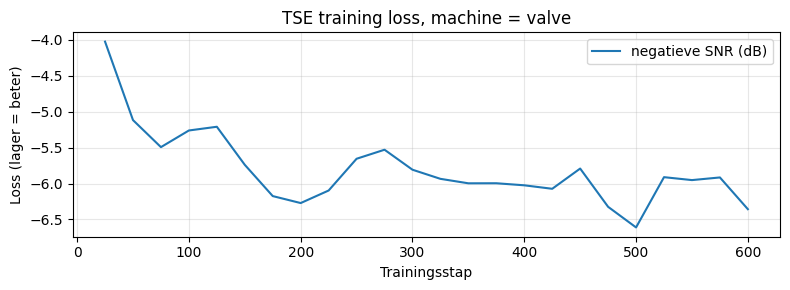

In [25]:
if not RUN_TSE:
    pass  # TSE-train reeds overgeslagen
else:
    # TSE training loop met loss logging, zodat we de grafiek van de loss in een volgende cel kunnen plotten
    from tqdm import tqdm  # voortgangsbalk

    tse_loss_history = []  # (step, mean_loss_so_far_in_window) tuples voor de plot
    tse_step = 0  # totaal aantal gedane stappen
    running = 0.0  # som van loss in het huidige log venster
    LOG_EVERY = 25  # elke 25 stappen loggen

    # zorg dat training reproduceerbaar is
    random.seed(0)
    torch.manual_seed(0)
    if tse_device.type == "cuda":
        torch.cuda.manual_seed_all(0)

    pbar = tqdm(total=TSE_NOTEBOOK_STEPS, desc=f"TSE[{TSE_TARGET_MACHINE}]")

    # we herhalen de dataloader totdat we genoeg stappen hebben
    while tse_step < TSE_NOTEBOOK_STEPS:
        tse_model.train()  # train modus voor batchnorm
        for clean in tse_loader:
            if tse_step >= TSE_NOTEBOOK_STEPS:
                break
            clean = clean.to(tse_device, non_blocking=True)  # [batch, tijd]

            # voor elk voorbeeld in de batch: trek een ruis sample en mix op random snr
            noisy_list = []
            for i in range(clean.shape[0]):
                noise = noise_bank.sample(length=clean.shape[-1]).to(tse_device)  # zelfde lengte als clean
                mixed = mix_at_random_snr(clean[i], noise, snr_db_range=(-5.0, 5.0))  # [-5, 5] db zoals Fujimura
                noisy_list.append(mixed)
            noisy = torch.stack(noisy_list, dim=0)  # stapel tot batch tensor

            # forward door het TSE model, geeft een geschatte schone waveform
            enhanced = tse_model(noisy)

            # negatieve SNR tussen schatting en de originele schone waveform
            loss = neg_snr_loss(enhanced, clean)

            # standaard optimizer stap
            tse_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(tse_model.parameters(), max_norm=5.0)  # gradient clip zoals Fujimura
            tse_optimizer.step()

            running += float(loss.item())
            tse_step += 1
            pbar.update(1)

            # periodiek loss samenvatten en opslaan voor de plot
            if tse_step % LOG_EVERY == 0:
                avg = running / LOG_EVERY
                tse_loss_history.append((tse_step, avg))
                pbar.set_postfix({"neg_snr_db": f"{avg:.2f}"})
                running = 0.0

    pbar.close()
    print("TSE training demo klaar.")

    # direct een plot van de loss over de stappen
    if tse_loss_history:
        steps_arr = np.array([s for s, _ in tse_loss_history])
        loss_arr = np.array([v for _, v in tse_loss_history])
        plt.figure(figsize=(8, 3))
        plt.plot(steps_arr, loss_arr, label="negatieve SNR (dB)")
        plt.xlabel("Trainingsstap")
        plt.ylabel("Loss (lager = beter)")
        plt.title(f"TSE training loss, machine = {TSE_TARGET_MACHINE}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Geen loss history, verhoog TSE_NOTEBOOK_STEPS of LOG_EVERY.")

## Stap 19, Fujimura et al. (2025), 2.1: visueel controleren wat TSE doet

We pakken één test wav van onze doelmachine, mixen er kunstmatig ruis uit een andere machine doorheen, en laten het getrainde TSE model een ge-enhancede versie maken. Vervolgens plotten we drie panelen voor het spectrogram (schoon, ruisig, enhanced) en drie panelen voor de waveform. Zo zie je in één oogopslag of het model iets zinnigs doet en of het de machinestructuur bewaart.

De bovenste rij is een log-magnitude-spectrogram (tijd op de x-as, frequentie op de y-as; geel = meer energie). Vergelijk de drie panelen: Schoon doel = referentie, Ruisig = doel + ruis van een andere machine, TSE output = na het netwerk. Een nuttig model dempt vloer-ruis, maar houdt de karakteristieke patroonbanden (ritme) zichtbaar.

De onderste rij toont de golfvorm in de tijd: zie je of pieken/periodiek gedrag bewaard blijven. Onderaan: reconstructie-SNR in dB (hoger = dichter bij schone target); dezelfde definitie als `neg_snr_loss` / `train_tse_snellius.py` (`tse_loss.csv` op Snellius).


## Tussenstap: wat je straks in de figuur ziet

De volgende codecel maakt de plots. Voor uitleg aan teammates:

- Bovenste rij (3 panelen): log-magnitude spectrogram (geel is meer energie). Vergelijk, schoon (doel), dan Ruisig (doel plus ruis), dan TSE output. Ideaal: de output lijkt meer op schoon dan op ruisig, zonder alles flets te wissen.
- Onderste rij (3 panelen): dezelfde drie in de tijd (golfvorm), om pieken/periodiek nog eens te zien.
- In de pijplijn (Snellius: STEP 1) train je dit model per machine, hier train je vaak één machine ter demo.


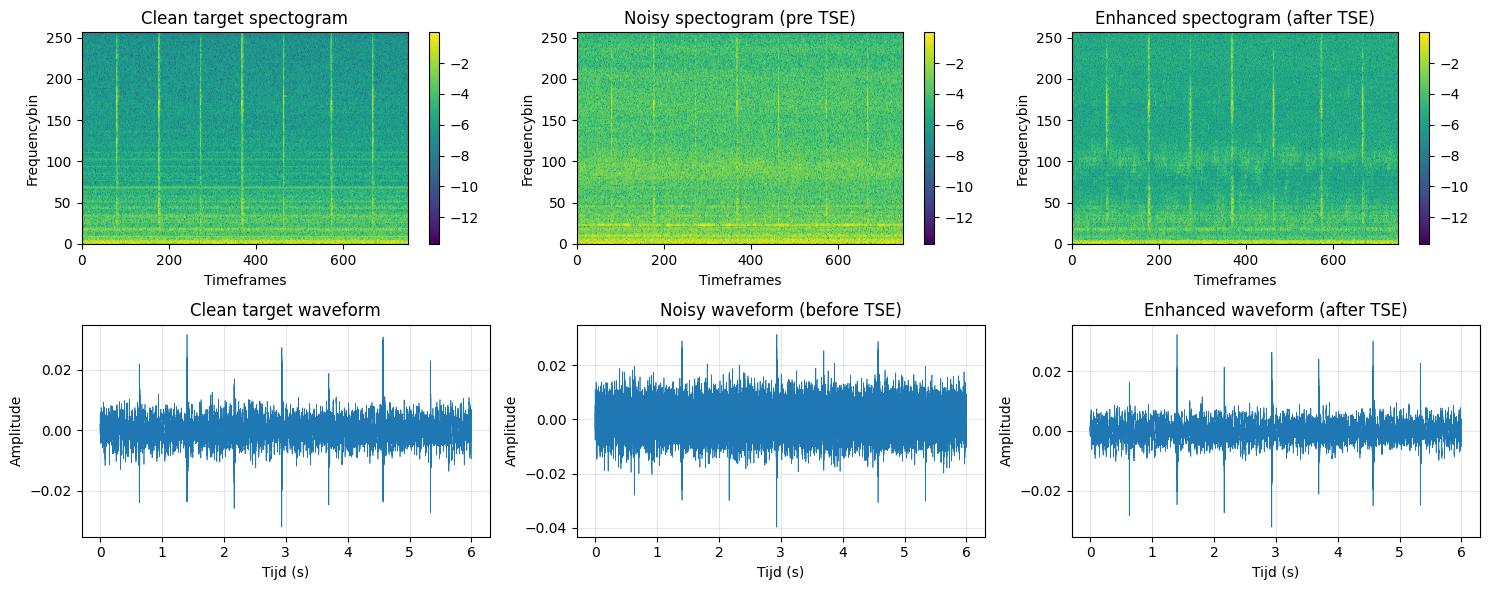

SNR voor enhancement: -0.00 dB
SNR na enhancement  : +7.43 dB
Winst               : +7.43 dB


In [33]:
# Volgorde: eerst toggle cel (RUN_TSE, TSE_MODE), dan imports, dan stap 18 train, dan deze cel.
if "RUN_TSE" not in globals():
    raise RuntimeError(
        "RUN_TSE is niet gezet. Voer eerst de toggle codecel uit (met RUN_TSE = True of False), "
        "daarna de import cel, daarna stap 18, en pas dan deze visualisatie (stap 19)."
    )
if RUN_TSE:
    _need = ["tse_model", "target_wavs", "noise_bank"]
    _miss = [n for n in _need if n not in globals()]
    if _miss:
        raise RuntimeError(
            f"Voor de plot ontbreekt: {', '.join(_miss)}. Voer stap 18 (TSE train demo) uit, "
            "of zet RUN_TSE = False in de toggle cel."
        )
if not RUN_TSE:
    print("RUN_TSE=False: geen TSE-spectrogram/waveform plot (zelfde als TSE fase uit op Snellius).")
else:
    # visuele controle: clean, noisy, enhanced voor één fragment

    tse_model.eval()  # eval modus om batchnorm vast te zetten

    # kies één schone doelfragment, we pakken gewoon de eerste train wav
    demo_clean_path = target_wavs[0]
    demo_clean = load_wav_mono(demo_clean_path, TSE_SAMPLE_RATE)  # 1D waveform
    demo_clean = pad_or_crop(demo_clean, int(TSE_SEGMENT_SECONDS * TSE_SAMPLE_RATE), random_crop=False)  # vaste lengte
    demo_clean = demo_clean - demo_clean.mean()  # dc offset verwijderen

    # trek een random ruis uit de ruisbank, met dezelfde lengte
    demo_noise = noise_bank.sample(length=demo_clean.shape[-1])
    # mix op een vaste snr van 0 db voor een duidelijke demo
    demo_noisy = mix_at_random_snr(demo_clean, demo_noise, snr_db_range=(0.0, 0.0))

    # enhancement door het model, we zetten de waveform op de gpu als één batch van grootte 1
    with torch.no_grad():
        enhanced = tse_model(demo_noisy.unsqueeze(0).to(tse_device)).cpu().squeeze(0)

    # helper: log magnitude spectrogram voor het plaatje
    def _log_mag_spec(wav, n_fft=512, hop=128, eps=1e-6):
        spec = torch.stft(wav, n_fft=n_fft, hop_length=hop, window=torch.hann_window(n_fft), return_complex=True)
        return torch.log(spec.abs() + eps).numpy()

    spec_clean = _log_mag_spec(demo_clean)
    spec_noisy = _log_mag_spec(demo_noisy)
    spec_enh = _log_mag_spec(enhanced)

    # plot alle panelen
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))

    specs = [
        (spec_clean, "Clean target spectogram"),
        (spec_noisy, "Noisy spectogram (pre TSE)"),
        (spec_enh, "Enhanced spectogram (after TSE)"),
    ]
    vmin = min(s[0].min() for s in specs)
    vmax = max(s[0].max() for s in specs)
    for ax, (spec, title) in zip(axes[0], specs):
        im = ax.imshow(spec, aspect="auto", origin="lower", interpolation="none", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Timeframes")
        ax.set_ylabel("Frequencybin")
        plt.colorbar(im, ax=ax)

    waves = [
        (demo_clean.numpy(), "Clean target waveform"),
        (demo_noisy.numpy(), "Noisy waveform (before TSE)"),
        (enhanced.numpy(), "Enhanced waveform (after TSE)"),
    ]
    t_axis = np.arange(demo_clean.shape[-1]) / TSE_SAMPLE_RATE
    for ax, (wav, title) in zip(axes[1], waves):
        ax.plot(t_axis, wav, linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel("Tijd (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # kwantitatieve maat: reconstructie-SNR (dB), zelfde definitie als neg_snr_loss / Fujimura L_D
    from tse_snellius import mean_snr_db
    with torch.no_grad():
        before = float(
            mean_snr_db(demo_noisy.unsqueeze(0), demo_clean.unsqueeze(0)).item()
        )
        after = float(
            mean_snr_db(enhanced.unsqueeze(0), demo_clean.unsqueeze(0)).item()
        )
    print(f"SNR voor enhancement: {before:+.2f} dB")
    print(f"SNR na enhancement  : {after:+.2f} dB")
    print(f"Winst               : {after - before:+.2f} dB")

## stap 20, wang (2025), 2.2 + 2.2.2: training loop (richting system-1 / eat-lora)

 dit is het echte fine-tunen, vooruit door het netwerk, arcface-loss, backward, optimizer. dat komt overeen met wangs eat-lora-systeem (in de paper system-1). 

(wang 2025, 2.2-2.2.2 (training); 2.3 knn en 2.5 ensemble volgen in hun volledige pipeline)

de dataset in stap 13 zet automatisch tse op de waveform vóór mel als er `checkpoints/tse` met `{machine}.pt` is, dezelfde volgorde als knn eval.


In [27]:
# scheduler past het leerpercentage aan na veel stappen hier elke vijfduizend stappen keer nul komma vijf
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)
from tqdm import tqdm
# python garbage collector ruimt soms losse objecten op
import gc

gc.collect()
# als cuda beschikbaar is maak gpu cache iets leger dit helpt soms tegen geheugen stress
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# totaal aantal optimizer stappen die we willen doen wang gebruikt veel meer voor serieus resultaat zet lager voor test
NUM_TRAIN_STEPS = 20000
# om de zoveel stappen tonen we gemiddelde loss in tqdm
LOG_INTERVAL = 100
# om de zoveel stappen een tussen bestand opslaan zet lager als je maar kort traint
SAVE_INTERVAL = 2000

# hoeveel stappen we al hebben gedaan
current_step = 0
# som van loss getallen voor gemiddelde over het log interval
running_loss = 0.0

print(f"Starting training for {NUM_TRAIN_STEPS} steps...")
# voortgangsbalk
pbar = tqdm(total=NUM_TRAIN_STEPS, desc="Training System-1")

# hoofdlus tot we genoeg stappen hebben
while current_step < NUM_TRAIN_STEPS:
    # train modus aan voor lora en dropout gedrag
    eat_lora.train()

    # volgende batch uit de dataloader
    for mel, labels in loader:
        # klaar als we het stappen budget bereiken
        if current_step >= NUM_TRAIN_STEPS:
            break

        # data naar gpu
        mel, labels = mel.cuda(), labels.cuda()

        # forward eat plus lora geeft embedding vectoren
        embeddings = eat_lora(mel)
        # arcface meet hoe goed embedding bij label hoort
        loss = criterion(embeddings, labels)

        # oude gradienten weg
        optimizer.zero_grad()
        # nieuwe gradienten uit loss
        loss.backward()
        # gewichten een stapje bijsturen
        optimizer.step()
        # leersnelheid schema ook een stap
        scheduler.step()

        # loss optellen voor gemiddelde
        running_loss += loss.item()
        current_step += 1
        pbar.update(1)

        # periodiek loss laten zien
        if current_step % LOG_INTERVAL == 0:
            avg_loss = running_loss / LOG_INTERVAL
            pbar.set_postfix({"loss": f"{avg_loss:.4f}"})
            running_loss = 0.0

        # periodiek checkpoint
        if current_step % SAVE_INTERVAL == 0:
            torch.save(
                {
                    "model_state_dict": eat_lora.state_dict(),
                    "arcface_state_dict": criterion.state_dict(),
                    "encoder": encoder,
                    "step": current_step,
                },
                os.path.join(SAVE_DIR, f"checkpoint_step_{current_step}.pt"),
            )

pbar.close()

# laatste staat altijd bewaren
torch.save(
    {
        "model_state_dict": eat_lora.state_dict(),
        "arcface_state_dict": criterion.state_dict(),
        "encoder": encoder,
        "step": current_step,
    },
    os.path.join(SAVE_DIR, "checkpoint_last.pt"),
)
print("Training complete")

Starting training for 20000 steps...


Training System-1:   0%|          | 0/20000 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 386.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 10.43 GiB is allocated by PyTorch, and 255.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# 2000 steps HPC check

In [ ]:
import torch

CHECKPOINT_PATH = r"C:\Users\lucth\Downloads\Sorama Internship\Victor_week_9\checkpoints\eat_lora_system1\checkpoint_step_6000.pt"  # pas aan

device = "cuda" if torch.cuda.is_available() else "cpu"
eat_lora = EATAnomalousTrainer(model).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
eat_lora.load_state_dict(ckpt["model_state_dict"], strict=True)
eat_lora.eval()
print("Loaded checkpoint:", CHECKPOINT_PATH)

C:\Users\lucth\AppData\Local\Temp\ipykernel_27080\2326289404.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=device)


Loaded checkpoint: C:\Users\lucth\Downloads\Sorama Internship\Victor_week_9\checkpoints\eat_lora_system1\checkpoint_step_6000.pt


## Stap 21, Wang (2025), 2.3 KNN anomaly score, AUC en pAUC (development data)

Zelfde idee als Wang, embeddings van normale train fragmenten als bibliotheek, voor elk test fragment de kleinste cosinus-afstand (1 minus maximale cosinus-similariteit) als anomaly score. Hoe hoger de score, hoe verder van de normale bank. In het volgende wordt uitgelegd hoe de codecell (geïnspireerd door de officiële dcase2025_task_2_evaluator.py) hieronder werkt:

1. Pad naar de data  
   `BASE_PATH` wijst naar de map `raw` met per machine-type submappen (`bearing`, `valve`, …). Als die variabele nog niet bestaat, zoekt de code een logische map ten opzichte van je werkmap.

2. Voorwaarden  

   `eat_lora` en `_resolve_train_wav_path` moeten al bestaan (uit eerdere notebookcellen). Zonder die twee kan deze cel niet draaien.

3. Labels uit de naam  

   `_dev_row_to_label_and_domain` kijkt alleen naar tekst in het pad: `test_anomaly` → label “anomalie”, `test_normal` → “normaal”. `source` of geen `source` → domein voor aparte AUC’s (zoals bij DCASE).

4. Van wav naar mel 

   `load_mel_from_wav_path` leest audio, zet naar 16 kHz, maakt een mel-spectrogram op dezelfde manier als in jullie EAT-pijplijn en knipt of vult tot vaste lengte.

5. Van mel naar embedding 

   `embed_mel_batch` stuurt mel-batches door `eat_lora` op de GPU en normaliseert de uitvoer. Dat zijn de punten waartussen je afstanden meet.

6. Anomaly score (KNN-idee) 

   Voor elke test-vector: hoogste cosinus-gelijkheid met een willekeurige train-normaal in de bank. Score = 1 minus die hoogste gelijkheid. Dicht bij de bank → lage score; ver weg → hoge score (meer “anomalieachtig” volgens deze maat).

7. Trainbank uit mappen  

   `wav_rows_train_normal` verzamelt alle `.wav` in `…/machine/train/` waarvan de naam lijkt op DCASE train + normal (geen `anomaly`). 

8. Testlijst uit mappen  

   `wav_rows_test_labeled` verzamelt `.wav` in `…/machine/test/` waarvan de naam een geldige test-label en domein oplevert.

9. Hoofdlus per machine  

   Voor elke submap van `raw`: bouw bank-mels, embed de hele bank, bouw test-mels, embed test, bereken scores, vergelijk met labels.





In [ ]:
# uitleg wang knn evaluatie train en test uit mappen zonder attributes csv
import os  # paden en mappen
import sys  # kleinste float voor hmean
import numpy as np  # arrays en rekenen
import pandas as pd  # tabellen voor rijen
import torch  # tensor en gpu
import torchaudio  # wav inladen en mel
from scipy import stats  # harmonisch gemiddelde
from sklearn import metrics  # auc en pauc

MAX_FPR = 0.1  # max false positive rate voor pauc zoals evaluator

if "BASE_PATH" not in globals():  # pad nog niet gezet door eerdere cellen
    _here = os.getcwd()  # huidige werkmap van het notebook
    _candidates = [  # lijst mogelijke mappen naar raw data
        os.path.join(_here, "data", "dcase2025t2", "dev_data", "raw"),
        os.path.join(_here, "..", "data", "dcase2025t2", "dev_data", "raw"),
    ]
    BASE_PATH = next((p for p in _candidates if os.path.isdir(p)), _candidates[0])  # eerste map die bestaat of fallback
BASE_PATH = os.path.normpath(BASE_PATH)  # schone padnotatie voor het os

if "eat_lora" not in globals() or "_resolve_train_wav_path" not in globals():  # model of padhelper ontbreekt
    raise NameError(  # stop met duidelijke fout
        "eat_lora en/of _resolve_train_wav_path ontbreekt. run eerst de cellen met EATDCASEDataset en eat_lora."
    )

def _dev_row_to_label_and_domain(fn: str):  # label en domein uit relatieve bestandsnaam
    fn = str(fn).replace("\\", "/")  # windows slashes naar forward slash
    if "test_anomaly" in fn:  # anomalie clip volgens naam
        y = 1  # positieve klasse
    elif "test_normal" in fn:  # normale test clip
        y = 0  # negatieve klasse
    else:  # geen test label in naam
        return None, None  # deze file slaan we over
    domain = "source" if "source" in fn else "target"  # bron of doel domein uit naam
    return y, domain  # klaar voor evaluatie


def load_mel_from_wav_path(file_path: str, target_length: int = 1024):  # een wav naar eat stijl mel
    waveform, sr = torchaudio.load(file_path)  # stereo of mono en sample rate
    if sr != 16000:  # eat verwacht zestien khz
        waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)  # hersamplen
    waveform = waveform - waveform.mean()  # dc offset weg
    mel = torchaudio.compliance.kaldi.fbank(  # log mel filterbank zoals kaldi
        waveform,
        htk_compat=True,
        sample_frequency=16000,
        use_energy=False,
        window_type="hanning",
        num_mel_bins=128,
        dither=0.0,
        frame_shift=10,
    )
    n_frames = mel.shape[0]  # aantal tijdsframes
    if n_frames < target_length:  # te kort
        mel = torch.nn.functional.pad(mel, (0, 0, 0, target_length - n_frames), "constant", 0)  # nullen onderaan
    else:  # te lang
        mel = mel[:target_length, :]  # knip op vaste lengte
    norm_mean, norm_std = -4.268, 4.569  # eat standaard normalisatie constanten
    mel = (mel - norm_mean) / (norm_std * 2)  # schaal zoals in het notebook
    return mel  # tensor terug voor batching


@torch.no_grad()  # geen gradients tijdens eval
def embed_mel_batch(mels_cpu: torch.Tensor):  # batch mels naar genormaliseerde embedding
    eat_lora.eval()  # dropout uit etc
    x = mels_cpu.cuda()  # naar gpu
    if x.dim() == 3:  # batch tijd freq
        x = x.unsqueeze(1)  # kanaaldimensie voor model
    e = eat_lora(x)  # voorwaartse stap
    return torch.nn.functional.normalize(e.float(), dim=1).cpu().numpy()  # l2 norm per rij terug naar numpy


def knn_min_cosine_distance_scores(bank: np.ndarray, queries: np.ndarray):  # anomaly score per test embedding
    """bank en queries zijn l2 genormaliseerd; wang gebruikt min cosinusafstand als score."""
    sim = queries @ bank.T  # cosinus sim want vectoren genormaliseerd
    max_sim = sim.max(axis=1)  # dichtste buur in de bank
    return (1.0 - max_sim).astype(np.float64)  # grote score is meer anomalie


def auc_pauc_all(y_true, y_score):  # roc auc op hele testset
    y_true = np.asarray(y_true, dtype=int)  # zeker int labels
    y_score = np.asarray(y_score, dtype=np.float64)  # zeker float scores
    if len(np.unique(y_true)) < 2:  # maar een klasse
        return float("nan"), float("nan")  # geen roc mogelijk
    auc = metrics.roc_auc_score(y_true, y_score)  # volledige roc
    pauc = metrics.roc_auc_score(y_true, y_score, max_fpr=MAX_FPR)  # roc tot max fpr
    return auc, pauc  # beide terug


def auc_domain_like_evaluator(y_true, y_score, y_domain_int, domain_idx: int):  # auc met evaluator mask
    """Zelfde mask als dcase2025_task2_evaluator: domein-normals + alle anomalies."""
    y_true = np.asarray(y_true, dtype=int)  # labels weer als array
    y_score = np.asarray(y_score, dtype=np.float64)  # scores weer als array
    y_domain_int = np.asarray(y_domain_int, dtype=int)  # nul is source een is target
    mask = (y_domain_int == domain_idx) | (y_true != 0)  # eigen domein normaal of elke anomalie
    yt = y_true[mask]  # gefilterde labels
    ys = y_score[mask]  # gefilterde scores
    if len(np.unique(yt)) < 2:  # geen twee klassen in subset
        return float("nan")  # geen auc
    return metrics.roc_auc_score(yt, ys)  # auc op subset


def wav_rows_train_normal(machine: str, base_path: str) -> pd.DataFrame:  # bouw train rijen uit map
    """train/*.wav, alleen normale trainclips (train + normal in naam, geen anomaly)."""
    train_dir = os.path.join(base_path, machine, "train")  # pad naar train map
    if not os.path.isdir(train_dir):  # map ontbreekt
        return pd.DataFrame()  # lege tabel
    rows = []  # verzamel file_name rijen
    for wav_name in sorted(os.listdir(train_dir)):  # vaste volgorde
        if not wav_name.lower().endswith(".wav"):  # geen audio
            continue  # volgende
        low = wav_name.lower()  # case onafhankelijk check
        if "anomaly" in low:  # geen anomalie in train bank
            continue  # sla over
        if "train" not in low or "normal" not in low:  # geen dcase train normal naam
            continue  # sla over
        rel = f"{machine}/train/{wav_name}"  # relatief pad voor resolver
        rows.append({"file_name": rel, "_machine": machine})  # rij zoals dataset verwacht
    return pd.DataFrame(rows)  # alle train files als dataframe


def wav_rows_test_labeled(machine: str, base_path: str) -> pd.DataFrame:  # bouw test rijen uit map
    """test/*.wav met test_normal/test_anomaly + source/target in bestandsnaam."""
    test_dir = os.path.join(base_path, machine, "test")  # pad naar test map
    if not os.path.isdir(test_dir):  # map ontbreekt
        return pd.DataFrame()  # leeg
    rows = []  # verzamel geldige test rijen
    for wav_name in sorted(os.listdir(test_dir)):  # vaste volgorde
        if not wav_name.lower().endswith(".wav"):  # geen audio
            continue  # volgende
        rel = f"{machine}/test/{wav_name}"  # relatief pad
        if _dev_row_to_label_and_domain(rel)[0] is None:  # geen label uit naam
            continue  # sla over
        rows.append({"file_name": rel, "_machine": machine})  # rij voor resolver
    return pd.DataFrame(rows)  # test dataframe


rows_out = []  # resultaten per machine
machine_dirs = sorted(  # alle submappen onder raw
    d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))
)

for machine in machine_dirs:  # per machine type
    train_df = wav_rows_train_normal(machine, BASE_PATH)  # train file lijst
    test_df = wav_rows_test_labeled(machine, BASE_PATH)  # test file lijst

    if len(train_df) == 0:  # geen train wavs gevonden
        print(f"[{machine}] skip: geen train/*.wav (train+normal in naam, geen anomaly)")
        continue  # volgende machine
    if len(test_df) == 0:  # geen gelabelde test wavs
        print(f"[{machine}] skip: geen test/*.wav met test_normal/test_anomaly in naam")
        continue  # volgende machine

    bank_mels = []  # lijst mel tensors voor bank
    skipped_tr = 0  # teller mislukte train files
    for _, row in train_df.iterrows():  # elke train file
        fp = _resolve_train_wav_path(BASE_PATH, row)  # absoluut pad
        if not os.path.isfile(fp):  # mist op schijf
            skipped_tr += 1  # tel fout
            continue  # volgende
        try:  # laad veilig
            bank_mels.append(load_mel_from_wav_path(fp))  # mel toevoegen
        except Exception as ex:  # corrupt of decode fout
            skipped_tr += 1  # tel fout
            print(f"[{machine}] train wav fout {fp}: {ex}")  # meld
    if len(bank_mels) == 0:  # niets geladen
        print(f"[{machine}] skip: geen train wav geladen (overgeslagen {skipped_tr})")
        continue  # volgende machine

    bank_t = torch.stack(bank_mels, dim=0)  # tensor batch dim n train
    bank_emb = []  # lijst embedding chunks
    bs = 8  # batch grootte voor gpu
    for i in range(0, len(bank_t), bs):  # in stukken
        bank_emb.append(embed_mel_batch(bank_t[i : i + bs]))  # forward per stuk
    bank_np = np.concatenate(bank_emb, axis=0)  # volledige bank matrix

    test_mels = []  # test mel tensors
    y_list = []  # labels zero of een
    dom_list = []  # source of target string
    skipped_te = 0  # teller mislukte test files
    for _, row in test_df.iterrows():  # elke test file
        fp = _resolve_train_wav_path(BASE_PATH, row)  # absoluut pad zelfde helper
        lab, dom = _dev_row_to_label_and_domain(row["file_name"])  # uit relatieve naam
        if lab is None:  # zou niet moeten na filter
            continue  # voor de zekerheid
        if not os.path.isfile(fp):  # mist op schijf
            skipped_te += 1  # tel fout
            continue  # volgende
        try:  # laad veilig
            test_mels.append(load_mel_from_wav_path(fp))  # mel
            y_list.append(lab)  # ground truth
            dom_list.append(dom)  # domein voor subset auc
        except Exception as ex:  # fout bij lezen
            skipped_te += 1  # tel fout
            print(f"[{machine}] test wav fout {fp}: {ex}")  # meld
    if len(test_mels) == 0:  # geen test geladen
        print(f"[{machine}] skip: geen test wav (overgeslagen {skipped_te})")
        continue  # volgende machine

    te_t = torch.stack(test_mels, dim=0)  # test batch tensor
    q_emb = []  # query embeddings chunks
    for i in range(0, len(te_t), bs):  # zelfde batch grootte
        q_emb.append(embed_mel_batch(te_t[i : i + bs]))  # forward
    q_np = np.concatenate(q_emb, axis=0)  # alle test embeddings

    y_true = np.array(y_list, dtype=int)  # labels als array
    y_domain_int = np.array([0 if d == "source" else 1 for d in dom_list], dtype=int)  # ints voor mask
    y_score = knn_min_cosine_distance_scores(bank_np, q_np)  # anomaly scores

    auc_all, pauc = auc_pauc_all(y_true, y_score)  # globale metrics
    auc_src = auc_domain_like_evaluator(y_true, y_score, y_domain_int, 0)  # source subset
    auc_tgt = auc_domain_like_evaluator(y_true, y_score, y_domain_int, 1)  # target subset

    rows_out.append(  # rij voor samenvatting
        {
            "machine": machine,
            "n_bank": len(bank_np),
            "n_test": len(y_true),
            "skipped_train_wav": skipped_tr,
            "skipped_test_wav": skipped_te,
            "AUC_all": auc_all,
            "pAUC": pauc,
            "AUC_source": auc_src,
            "AUC_target": auc_tgt,
        }
    )
    print(  # directe feedback per machine
        f"{machine}: AUC_all={auc_all:.4f} pAUC={pauc:.4f} "
        f"AUC_src={auc_src:.4f} AUC_tgt={auc_tgt:.4f}  bank={len(bank_np)} test={len(y_true)}"
    )

if not rows_out:  # geen enkele machine gelukt
    print("Geen machines geëvalueerd. Controleer BASE_PATH en of .wav bestanden bestaan.")
    print("BASE_PATH gebruikt:", os.path.abspath(BASE_PATH))
else:  # wel resultaten
    summary = pd.DataFrame(rows_out).set_index("machine")  # tabel index per machine
    display(summary)  # notebook weergave

    valid = summary["AUC_all"].notna()  # machines waar auc bestaat
    if valid.any():  # minstens een geldige auc
        print(
            "\nArithmetic mean over machines, AUC_all:",
            float(summary.loc[valid, "AUC_all"].mean()),
            " pAUC:",
            float(summary.loc[valid, "pAUC"].mean()),
            " AUC_source:",
            float(summary.loc[valid, "AUC_source"].mean()),
            " AUC_target:",
            float(summary.loc[valid, "AUC_target"].mean()),
        )
        flat = []  # waarden voor hmean
        for m in summary.loc[valid].index:  # per machine
            r = summary.loc[m]  # rij
            flat.extend([r["AUC_source"], r["AUC_target"], r["pAUC"]])  # drie getallen
        flat = np.maximum(np.array(flat, dtype=np.float64), sys.float_info.epsilon)  # voorkom nul in hmean
        print(
            "Harmonic mean (AUC_src, AUC_tgt, pAUC per machine), zoals official score pooling in evaluator:",
            float(stats.hmean(flat)),
        )

ToyCar: AUC_all=0.6643 pAUC=0.5011 AUC_src=0.6726 AUC_tgt=0.6560  bank=1000 test=200
ToyTrain: AUC_all=0.6727 pAUC=0.5137 AUC_src=0.8012 AUC_tgt=0.5442  bank=1000 test=200
bearing: AUC_all=0.5998 pAUC=0.5516 AUC_src=0.6900 AUC_tgt=0.5096  bank=1000 test=200
fan: AUC_all=0.5222 pAUC=0.5184 AUC_src=0.7052 AUC_tgt=0.3392  bank=1000 test=200
gearbox: AUC_all=0.6491 pAUC=0.5653 AUC_src=0.7668 AUC_tgt=0.5314  bank=1000 test=200
slider: AUC_all=0.7047 pAUC=0.5289 AUC_src=0.7940 AUC_tgt=0.6154  bank=1000 test=200
valve: AUC_all=0.7764 pAUC=0.6168 AUC_src=0.7302 AUC_tgt=0.8226  bank=1000 test=200


,n_bank,n_test,skipped_train_wav,skipped_test_wav,AUC_all,pAUC,AUC_source,AUC_target
machine,,,,,,,,
ToyCar,1000,200,0,0,0.6643,0.501053,0.6726,0.6560
ToyTrain,1000,200,0,0,0.6727,0.513684,0.8012,0.5442
bearing,1000,200,0,0,0.5998,0.551579,0.6900,0.5096
fan,1000,200,0,0,0.5222,0.518421,0.7052,0.3392
gearbox,1000,200,0,0,0.6491,0.565263,0.7668,0.5314
slider,1000,200,0,0,0.7047,0.528947,0.7940,0.6154
valve,1000,200,0,0,0.7764,0.616842,0.7302,0.8226



Arithmetic mean over machines — AUC_all: 0.6555999999999998  pAUC: 0.5422556390977443  AUC_source: 0.7371428571428572  AUC_target: 0.5740571428571429
Harmonic mean (AUC_src, AUC_tgt, pAUC per machine), zoals official score pooling in evaluator: 0.5916273872340202


Stap 21 hierboven vult Wang 2.3 (KNN scores, AUC/pAUC op development data) aan. Nog niet in dit notebook: 2.4 mechanische analyse (-MA), en 2.5 ensemble. Voor de officiële evaluatie-CSV workflow zie DCASE evaluation/03_evaluation_eval_data.sh.


## Stap 22, Fujimura et al. (2025), 2.3: KNN evaluatie met TSE, vergeleken met baseline

Fujimura et al. (2025) beschrijven strategieën om TSE in de ASD pijplijn te gebruiken (Section 2.3). Op Snellius staat **standaard `TSE_MODE=both`** (TSE op KNN-bank en test) en **Stap B: `EAT_TSE_IN_TRAINING=0`**: EAT traint op **ruwe** waveforms; TSE-checkpoints uit STEP 1 worden alleen in KNN gebruikt. Voor **Stap A** (TSE ook in de EAT-loop): `export EAT_TSE_IN_TRAINING=1` vóór `sbatch` of `EAT_TSE_IN_TRAINING = True` in de toggle cel.

Met `TSE_MODE=test-only` alleen test enhanced en de bank ruw — dat geeft vaak slechtere KNN-scores.

Kwalitatief TSE zonder EAT: op Snellius schrijft `train_tse_snellius.py` met `--loss-csv` o.a. gemiddelde **negatieve SNR** (trainingsloss) in `tse_loss.csv` (lager = beter; zelfde `neg_snr_loss` als hier). Onderin de codecel: één korte **SNR (dB)** check op een mix, hoger = beter.

Voor de command line eval op Snellius (default both):

```bash
python -u eval_wang2025_knn_snellius.py \
  --data-root "$SCRATCH_DATA_ROOT" \
  --checkpoint "$SAVE_DIR/checkpoint_last.pt" \
  --tse-checkpoint-dir "$PROJECT_DIR/checkpoints/tse" \
  --tse-mode both \
  --output-csv "$RESULTS_DIR/knn_eval_tse_both.csv"
```

`plot_knn_performance.py` pakt baseline en TSE apart als lijnen; geen zigzag. Reference: Fujimura et al., 2025, Section 2.3.

In [ ]:
if not RUN_TSE:
    print(
        "Stap 22: RUN_TSE=False. Geen tse_model in dit notebook (zoals op Snellius zonder TSE-train).\n"
        "Zet RUN_TSE=True en draai stap 18-19, of laad eerder `checkpoints/tse/*.pt`, en voer opnieuw uit."
    )
else:
    # sla het TSE checkpoint op zodat eval_wang2025_knn_snellius.py het kan inladen
    tse_ckpt_dir = os.path.join("checkpoints", "tse")
    os.makedirs(tse_ckpt_dir, exist_ok=True)
    tse_ckpt_path = os.path.join(tse_ckpt_dir, f"{TSE_TARGET_MACHINE}.pt")
    torch.save(
        {
            "model_state_dict": tse_model.state_dict(),
            "machine": TSE_TARGET_MACHINE,
            "num_steps": tse_step,
        },
        tse_ckpt_path,
    )
    print(f"TSE checkpoint opgeslagen in: {tse_ckpt_path}")

    # één korte SNR (dB) meting, los van EAT (zelfde mean_snr_db als in tse_snellius)
    from tse_snellius import mean_snr_db
    tse_model.eval()
    with torch.no_grad():
        c = load_wav_mono(target_wavs[0], TSE_SAMPLE_RATE)
        c = pad_or_crop(c, int(TSE_SEGMENT_SECONDS * TSE_SAMPLE_RATE), random_crop=True)
        c = c - c.mean()
        c_dev = c.to(tse_device)
        n = noise_bank.sample(c_dev.shape[0]).to(tse_device)
        m = mix_at_random_snr(c_dev, n, snr_db_range=(-5.0, 5.0))
        e = tse_model(m.unsqueeze(0)).squeeze(0)
        snr1 = float(mean_snr_db(e.unsqueeze(0), c_dev.unsqueeze(0)).item())
        print("Voorbeeld SNR (dB) op 1 mix, hoger is beter:", f"{snr1:.2f}")

    # KNN evaluatie opnieuw draaien voor alleen de doelmachine, met en zonder TSE
    # we hergebruiken helpers uit Stap 21. Die bestaan alleen als Stap 21 al is gerund.
    if any(n not in globals() for n in (
        "load_mel_from_wav_path",
        "embed_mel_batch",
        "wav_rows_train_normal",
        "wav_rows_test_labeled",
        "_resolve_train_wav_path",
        "knn_min_cosine_distance_scores",
        "auc_pauc_all",
        "auc_domain_like_evaluator",
    )):
        print("Run eerst Stap 21 (de KNN evaluatie cel) voordat je deze cel draait.")
    else:
        import pandas as pd
        import torchaudio

        # aparte versie van load_mel die optioneel eerst TSE toepast op de waveform
        def load_mel_with_optional_tse(file_path: str, use_tse: bool, target_length: int = 1024):
            waveform, sr = torchaudio.load(file_path)  # stereo of mono en sr
            if waveform.shape[0] > 1:  # stereo naar mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if sr != 16000:  # hersample als nodig
                waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
            waveform = waveform - waveform.mean()  # dc offset weg

            if use_tse:  # True voor bank en/of test afhankelijk van TSE_MODE (both / test-only)
                with torch.no_grad():
                    waveform = tse_model(waveform.to(tse_device)).cpu()

            mel = torchaudio.compliance.kaldi.fbank(  # mel precies zoals elders in de notebook
                waveform,
                htk_compat=True,
                sample_frequency=16000,
                use_energy=False,
                window_type="hanning",
                num_mel_bins=128,
                dither=0.0,
                frame_shift=10,
            )
            n_frames = mel.shape[0]
            if n_frames < target_length:  # te kort, pad met nullen
                mel = torch.nn.functional.pad(mel, (0, 0, 0, target_length - n_frames), "constant", 0)
            else:  # te lang, knip
                mel = mel[:target_length, :]
            norm_mean, norm_std = -4.268, 4.569  # dezelfde constanten als EAT training
            mel = (mel - norm_mean) / (norm_std * 2)
            return mel

        def eval_machine(machine: str, tse_mode: str):
            """tse_mode: off, test-only, of both (Fujimura Enh, Enh, zelfde als eval --tse-mode)."""
            train_df = wav_rows_train_normal(machine, BASE_PATH)
            test_df = wav_rows_test_labeled(machine, BASE_PATH)
            if len(train_df) == 0 or len(test_df) == 0:
                return None
            tse_on_bank = tse_mode == "both"
            tse_on_test = tse_mode in ("test-only", "both")
            if tse_mode not in ("off", "test-only", "both"):
                raise ValueError("tse_mode moet off, test-only, of both zijn")
            # train-bank: alleen TSE in both (Snellius default in stap 3)
            bank_mels = []
            for _, row in train_df.iterrows():
                fp = _resolve_train_wav_path(BASE_PATH, row)
                if not os.path.isfile(fp):
                    continue
                bank_mels.append(load_mel_with_optional_tse(fp, use_tse=tse_on_bank))
            if not bank_mels:
                return None
            bank_t = torch.stack(bank_mels, dim=0)
            bank_emb = []
            bs = 8
            for i in range(0, len(bank_t), bs):
                bank_emb.append(embed_mel_batch(bank_t[i : i + bs]))
            bank_np = np.concatenate(bank_emb, axis=0)
            # test: TSE in test-only en both
            test_mels, y_list, dom_list = [], [], []
            for _, row in test_df.iterrows():
                fp = _resolve_train_wav_path(BASE_PATH, row)
                fn = row["file_name"]
                y = 1 if "test_anomaly" in fn else (0 if "test_normal" in fn else None)
                if y is None or not os.path.isfile(fp):
                    continue
                test_mels.append(load_mel_with_optional_tse(fp, use_tse=tse_on_test))
                y_list.append(y)
                dom_list.append("source" if "source" in fn else "target")
            if not test_mels:
                return None
            te_t = torch.stack(test_mels, dim=0)
            q_emb = []
            for i in range(0, len(te_t), bs):
                q_emb.append(embed_mel_batch(te_t[i : i + bs]))
            q_np = np.concatenate(q_emb, axis=0)
            y_true = np.array(y_list, dtype=int)
            y_domain = np.array([0 if d == "source" else 1 for d in dom_list], dtype=int)
            y_score = knn_min_cosine_distance_scores(bank_np, q_np)
            auc_all, pauc = auc_pauc_all(y_true, y_score)
            auc_src = auc_domain_like_evaluator(y_true, y_score, y_domain, 0)
            auc_tgt = auc_domain_like_evaluator(y_true, y_score, y_domain, 1)
            return {
                "machine": machine,
                "AUC_all": auc_all,
                "pAUC": pauc,
                "AUC_source": auc_src,
                "AUC_target": auc_tgt,
            }

        res_baseline = eval_machine(TSE_TARGET_MACHINE, "off")
        res_tse_to = eval_machine(TSE_TARGET_MACHINE, "test-only")
        res_tse_both = eval_machine(TSE_TARGET_MACHINE, "both")
        rows_out = []
        for label, r in [
            ("off (geen TSE)", res_baseline),
            ("tse test-only", res_tse_to),
            ("tse both (bank + test)", res_tse_both),
        ]:
            if r is not None:
                rows_out.append({"strategy": label, **r})
        cmp_df = pd.DataFrame(rows_out) if rows_out else pd.DataFrame()
        print("\nKNN vergelijking, machine =", TSE_TARGET_MACHINE)
        try:
            display(cmp_df)
        except NameError:
            print(cmp_df.to_string(index=False))